First rows of dataset:
             timestamp           src_ip           dst_ip  src_port  dst_port  \
0  2025-10-01 00:12:54   188.176.27.165  253.240.113.218     56377       445   
1  2025-10-01 00:23:43      68.59.26.43    212.75.38.111     51165      1433   
2  2025-10-01 00:25:46   119.204.243.78     90.28.90.234     14948      1433   
3  2025-10-01 00:27:21  122.119.194.175   175.140.78.230     36097       443   
4  2025-10-01 00:40:09   181.199.242.68     55.99.177.69       445     21255   

  protocol  bytes_sent  bytes_received  \
0      TCP        8029           17204   
1      TCP      676368         2643374   
2      TCP      316502           38571   
3      TCP       70933           21935   
4      TCP       12721            9939   

                                          user_agent  \
0  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
1  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...   
2  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...   
3  Mozilla/5.0 (Win

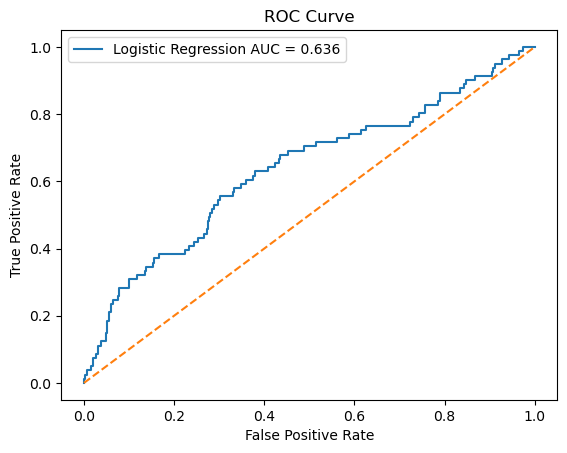

In [9]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv("cybersecurity.csv")

print("First rows of dataset:")
print(df.head())

print("\nDataset info:")
print(df.info())


# ================================
# 3. Drop Unnecessary Columns
# ================================
# These columns are mostly identifiers or high-cardinality text fields
# that are hard to use directly in a simple logistic regression model.
df = df.drop(columns=[
    "src_ip",
    "dst_ip",
    "timestamp",
    "url",
    "attack_type",
    "user_agent",
])


# ================================
# 4. Convert Boolean to Integer
# ================================
df["is_internal_traffic"] = df["is_internal_traffic"].astype(int)


# ================================
# 5. Encode Categorical Variables
# ================================
df = pd.get_dummies(df, columns=["protocol"], drop_first=True)


# ================================
# 6. Check Class Balance & Missing Values
# ================================
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts(normalize=True))


# ================================
# 7. Define Features and Target
# ================================
X = df.drop("label", axis=1)
y = df["label"]


# ================================
# 8. Train-Test Split (Stratified)
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # keep class proportions the same in train and test
)


# ================================
# 9. Preprocessing + Logistic Regression Pipeline
# ================================
# Separate numeric and (already one-hot) categorical columns
numeric_features = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "is_internal_traffic",
]

# Everything else that is not numeric_features is treated as categorical / already one-hot
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_features),
    ]
)

log_reg = LogisticRegression(
    max_iter=10000,
    class_weight="balanced",  # handle class imbalance more sensibly
    solver="lbfgs",
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("logreg", log_reg),
    ]
)

# Fit model
model.fit(X_train, y_train)


# ================================
# 10. Predictions
# ================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# ================================
# 11. Confusion Matrix
# ================================
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ================================
# 12. Classification Report
# ================================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ================================
# 13. ROC Curve and AUC
# ================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression AUC = " + str(round(auc, 3)))
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()